In [1]:
import sklearn
from sklearn.pipeline import Pipeline
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import cross_validate, StratifiedKFold, KFold
import numpy as np
from sklearn.datasets import load_iris
import pandas as pd
import os
import re 
import sys 
import importlib
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import (
	OneHotEncoder,
	OrdinalEncoder,
	RobustScaler,
)
from sklearn.preprocessing import (
	PowerTransformer, 
	QuantileTransformer
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer, StandardScaler, QuantileTransformer, Normalizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import cross_validate
sklearn.set_config(enable_metadata_routing=False)
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_selector as selector
from xgboost import XGBClassifier, XGBRegressor
import time 
import pandas as pd
import os
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.base import BaseEstimator, RegressorMixin
from scipy.stats import pearsonr
import plotly.express as px
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingRegressor
import numpy as np
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_absolute_error

import shap
shap.initjs()

# Get the absolute path of the project root
project_root = os.getcwd()
# Define data directory
brighten_dir = os.path.join(project_root, 'BRIGHTEN_data')
sub_dir = os.path.join(project_root, 'BRIGHTEN_data', 'sub_dfs')
results_dir = os.path.join(project_root, 'results')


# Add project root to sys.path for script usage
sys.path.append(project_root)

# Import and reload (optional) custom scripts
from scripts import preprocessing as pre
from scripts import visualization as vis
from scripts import variables 
from scripts import feature_selection as fs
importlib.reload(pre)
importlib.reload(vis)
importlib.reload(variables)
importlib.reload(fs)


################ DEFINE column variables from data ###################
from scripts.variables import id_columns
from scripts.variables import all_cols, all_daily_cols, weekly_cols, baseline_cols, drop_weekly_cols
from scripts.variables import daily_cols_v1, daily_v2_sensor_hr, daily_v2_weather, daily_cols_v2 
from scripts.variables import gad_cols, phq9_base, alc_cols, phq9_cols, phq2_cols, sleep_cols, gic_cols, sds_cols


# Define label variables
df_names = ['v1_day', 'v2_day', 'v1_week', 'v2_week']
aggregate_dfs = ['alldays_df','week_df']
# Update endings list if order changes


########################################## MODELS #######################################


# Models
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
# Dummy baseline model
class GroupMeanRegressor(BaseEstimator, RegressorMixin):
	def fit(self, X, y, groups):
		self.group_means_ = y.groupby(groups.squeeze()).mean().squeeze()
		self.global_mean_ = y.mean().squeeze()
		return self
	
	def predict(self, X, groups):
		return groups.squeeze().map(self.group_means_).fillna(self.global_mean_).values

# Pearson scorer
def pearsonr_scorer(y_true, y_pred):
	return pearsonr(y_true, y_pred)[0]

models = {
	'Random Forest': RandomForestRegressor(random_state=42),
	'XGBoost': XGBRegressor(objective='reg:squarederror', random_state=42),
	'Hist Gradient Boost': HistGradientBoostingRegressor(),
	'Group Mean': GroupMeanRegressor(),
	'Ridge': Ridge(alpha=1.0)
}
from sklearn.metrics import make_scorer
from scipy.stats import pearsonr

def pearsonr_scorer(y_true, y_pred):
	return pearsonr(y_true, y_pred)[0]

scoring_metrics = {
	'r2': 'r2',
	'neg_mae': 'neg_mean_absolute_error',
	'neg_rmse': 'neg_root_mean_squared_error',
}



# Do PCA on each subject's symptom/sensor structure
### This is specifically for within-subject activity and mood



DATAFRAME: v1_day
['phq2_2', 'race_2.0', 'user_phone_type', 'race_0.0', 'marital_status_1.0', 'season_fall', 'sms_count', 'season_num_3.0', 'sleep_2', 'sms_length', 'missed_interactions', 'race_6.0', 'mobility_radius', 'support', 'phq9_4', 'phq9_sum', 'season_num_2.0', 'income_lastyear', 'cohort_Akili', 'mood_1', 'phq9_7', 'mhs_sum', 'cohort_Health tips', 'gender_0.0', 'season_num_1.0', 'participant_id', 'race_3.0', 'stress', 'sds_2', 'marital_status_0.0', 'sds_3', 'season_num_4.0', 'gender_1.0', 'season_summer', 'month', 'phq9_3', 'phq9_6', 'phq2_sum', 'sds_1', 'phq9_cat', 'phq9_2', 'race_4.0', 'interaction_diversity', 'mobility', 'season_winter', 'call_duration', 'sleep_3', 'phq9_5', 'call_count', 'phq2_1', 'phq9_9', 'sleep_1', 'race_1.0', 'unreturned_calls', 'aggregate_communication', 'race_5.0', 'cohort_PST', 'phq9_1', 'marital_status_2.0', 'alc_cat', 'season_spring', 'phq9_8']
All cols for v1_day:
In df there are 238 subjects.


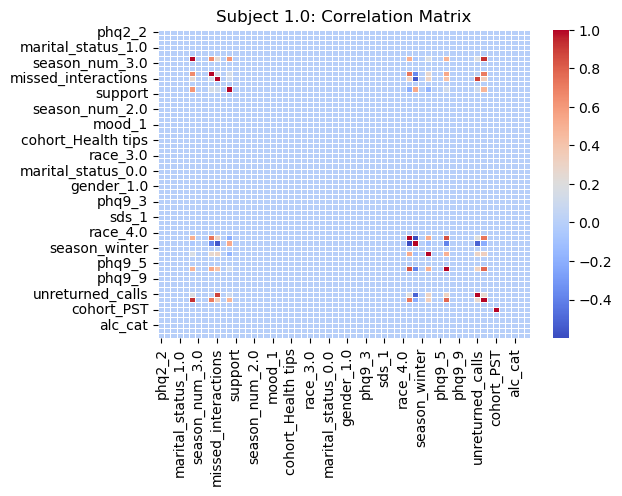

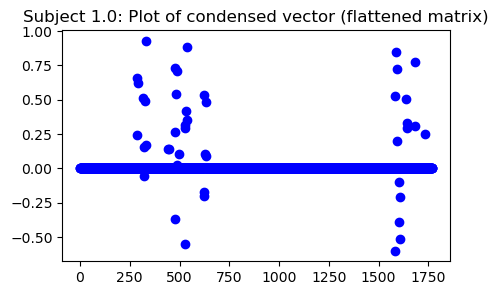

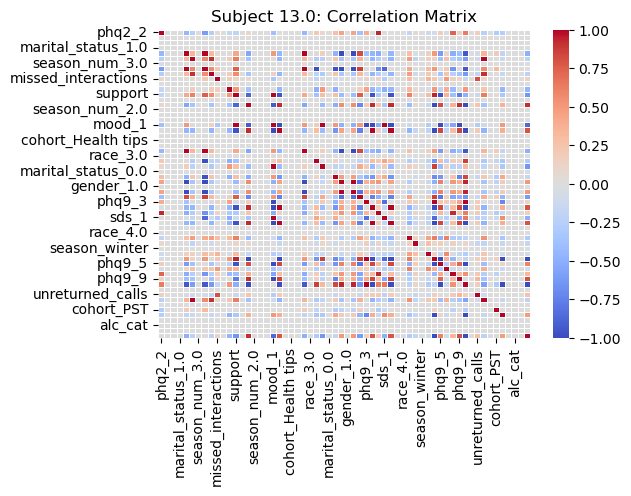

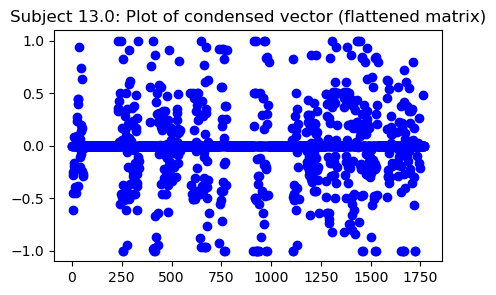

189 subs with symptom matrices
189 filled condensed arrays
Sensor cols for v1_day:
['mobility', 'mobility_radius', 'aggregate_communication', 'call_count', 'missed_interactions', 'sms_count', 'unreturned_calls', 'interaction_diversity', 'sms_length', 'call_duration']
In df there are 238 subjects.


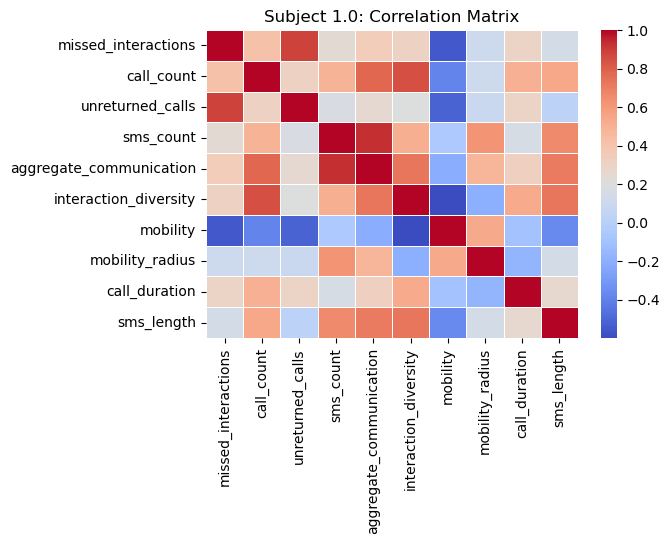

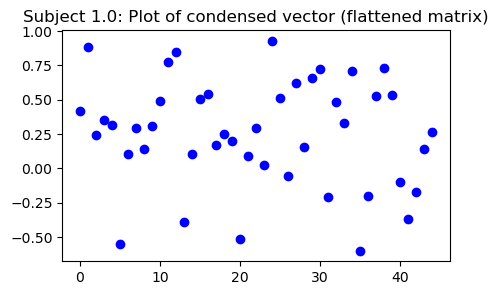

189 subs with symptom matrices
189 filled condensed arrays
Target cols for v1_day:
In df there are 238 subjects.


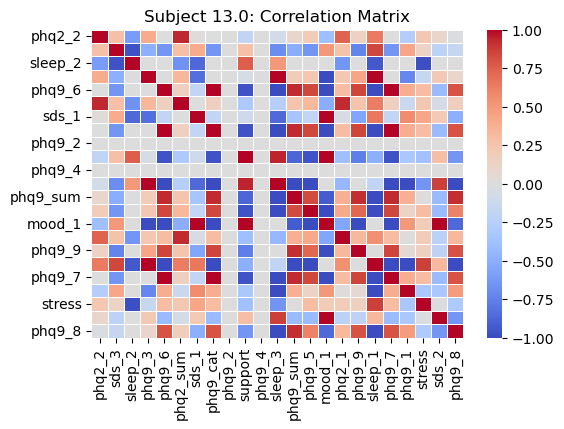

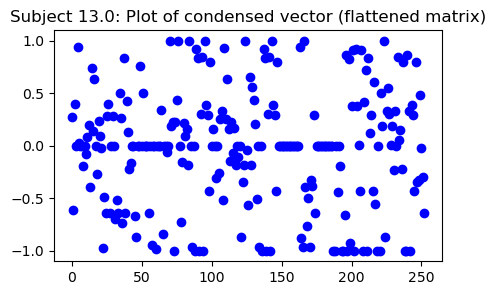

188 subs with symptom matrices
188 filled condensed arrays


DATAFRAME: v2_day
['phq2_2', 'sds_3', 'distance_walking', 'season_num_4.0', 'race_2.0', 'season_fall', 'marital_status_1.0', 'distance_walking_hr', 'race_0.0', 'distance_high_speed_transportation_hr', 'season_num_3.0', 'gender_1.0', 'sleep_2', 'season_summer', 'hours_stationary_nhw', 'month', 'phq9_3', 'came_to_work', 'phq9_6', 'phq2_sum', 'race_6.0', 'phq9_cat', 'sds_1', 'hours_accounted_for', 'distance_high_speed_transportation', 'phq9_2', 'distance_powered_vehicle', 'season_winter', 'support', 'hours_active_hr', 'phq9_4', 'phq9_sum', 'location_variance_hr', 'sleep_3', 'season_num_2.0', 'income_lastyear', 'phq9_5', 'hours_high_speed_transportation_hr', 'mood_1', 'hours_of_sleep_hr', 'phq2_1', 'phq9_9', 'race_7.0', 'location_variance', 'sleep_1', 'race_1.0', 'phq9_7', 'mhs_sum', 'hours_active', 'phq9_1', 'distance_active_hr', 'distance_active', 'hours_of_sleep', 'marital_status_2.0', 'hours_stationary', 'hours_high_speed_tra

/var/folders/fl/b24z_8kn4490x_bl0njv6fg00000gn/T/ipykernel_2047/3425606417.py:16: DtypeWarning: Columns (129) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_transformed.csv'))


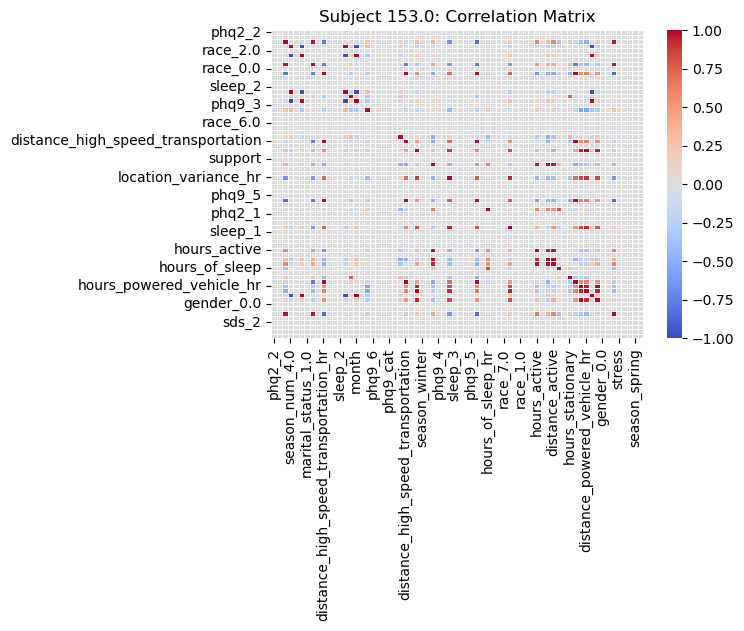

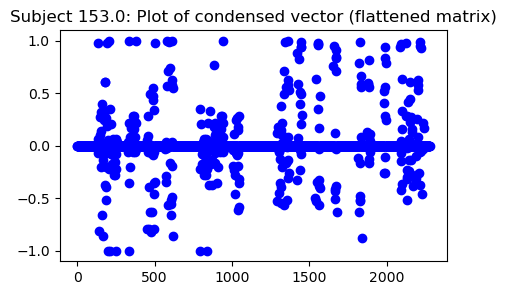

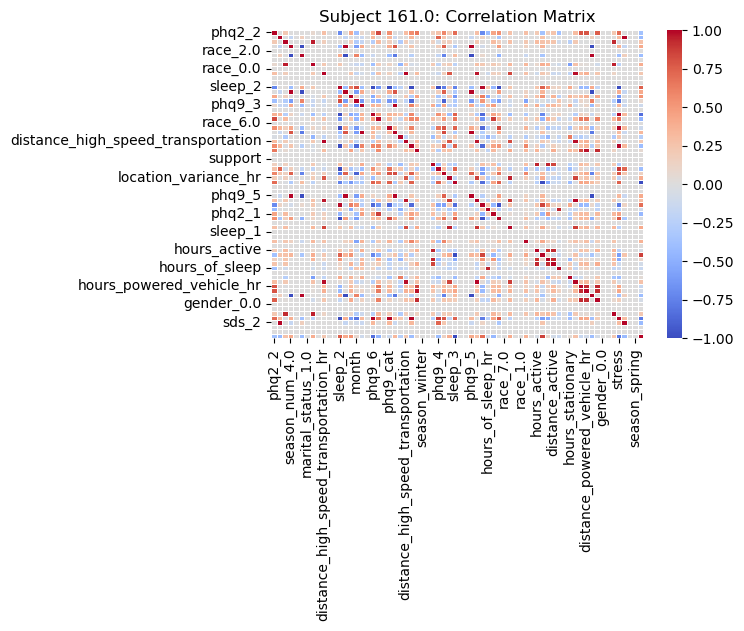

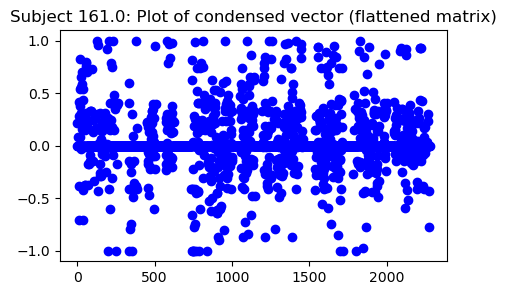

162 subs with symptom matrices
162 filled condensed arrays
Sensor cols for v2_day:
['came_to_work', 'hours_powered_vehicle_hr', 'precip_sum', 'hours_powered_vehicle', 'distance_powered_vehicle', 'distance_high_speed_transportation', 'hours_of_sleep', 'distance_active', 'location_variance', 'hours_active', 'distance_powered_vehicle_hr', 'dew_point_IQR', 'hours_high_speed_transportation_hr', 'distance_active_hr', 'cloud_cover_IQR', 'location_variance_hr', 'distance_high_speed_transportation_hr', 'hours_of_sleep_hr', 'hours_active_hr', 'dew_point_std', 'distance_walking_hr', 'hours_high_speed_transportation', 'distance_walking', 'dew_point_mean', 'humidity_mean', 'temp_mean', 'cloud_cover_mean', 'cloud_cover_median', 'humidity_std', 'dew_point_median', 'temp_std', 'temp_median', 'cloud_cover_std', 'temp_IQR', 'humidity_median', 'humidity_IQR']
In df there are 196 subjects.


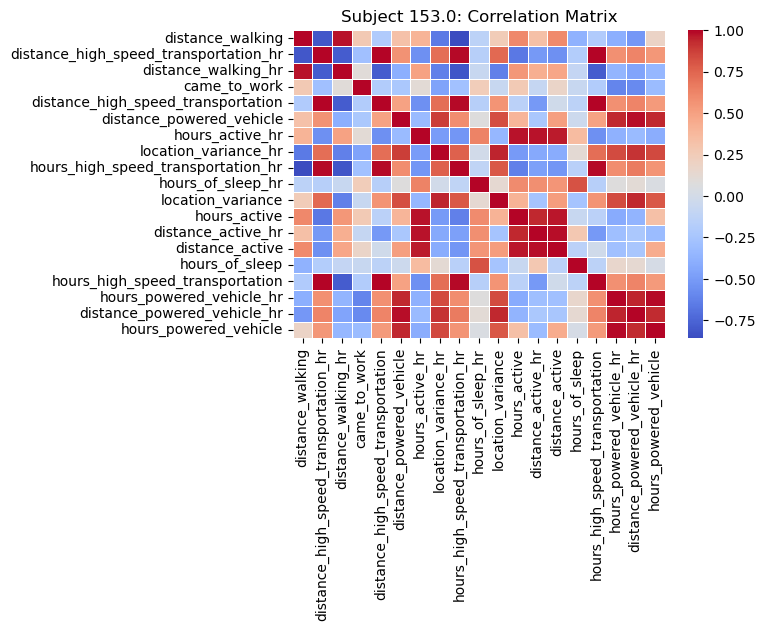

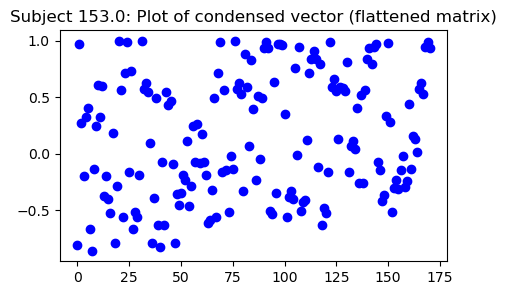

162 subs with symptom matrices
162 filled condensed arrays
Target cols for v2_day:
In df there are 196 subjects.


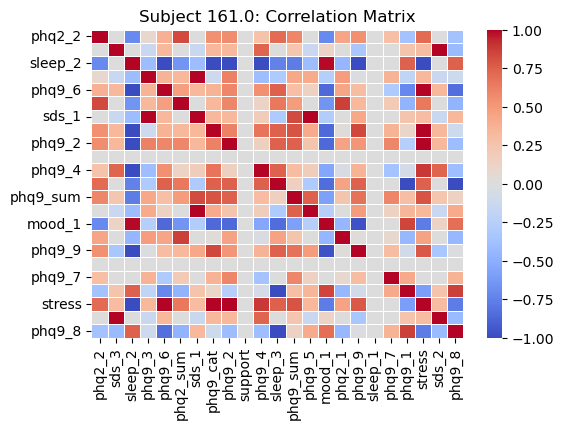

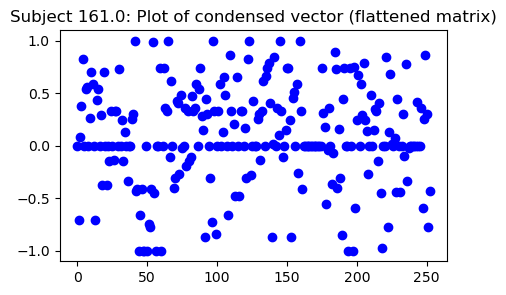

157 subs with symptom matrices
157 filled condensed arrays


DATAFRAME: v1_week
['phq2_2', 'race_2.0', 'user_phone_type', 'race_0.0', 'marital_status_1.0', 'season_fall', 'sms_count', 'season_num_3.0', 'sleep_2', 'sms_length', 'missed_interactions', 'race_6.0', 'mobility_radius', 'support', 'phq9_4', 'phq9_sum', 'season_num_2.0', 'income_lastyear', 'cohort_Akili', 'mood_1', 'phq9_7', 'mhs_sum', 'cohort_Health tips', 'gender_0.0', 'season_num_1.0', 'participant_id', 'race_3.0', 'stress', 'sds_2', 'marital_status_0.0', 'sds_3', 'season_num_4.0', 'gender_1.0', 'season_summer', 'month', 'phq9_3', 'phq9_6', 'phq2_sum', 'sds_1', 'phq9_cat', 'phq9_2', 'race_4.0', 'interaction_diversity', 'mobility', 'season_winter', 'call_duration', 'sleep_3', 'phq9_5', 'call_count', 'phq2_1', 'phq9_9', 'sleep_1', 'race_1.0', 'unreturned_calls', 'aggregate_communication', 'race_5.0', 'cohort_PST', 'phq9_1', 'marital_status_2.0', 'alc_cat', 'season_spring', 'phq9_8']
All cols for v1_week:
In df there are 238 s

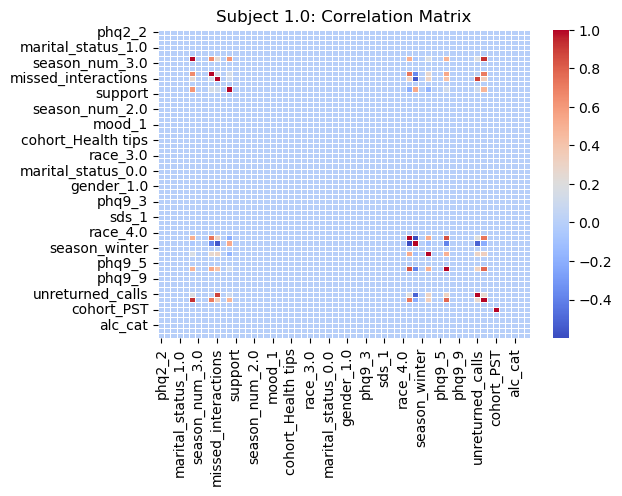

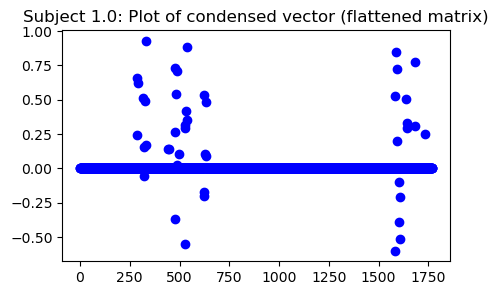

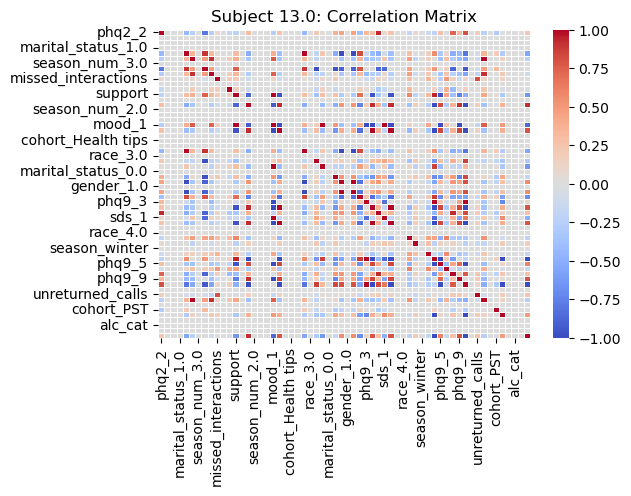

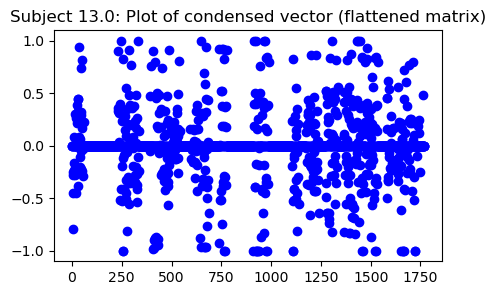

189 subs with symptom matrices
189 filled condensed arrays
Sensor cols for v1_week:
['mobility', 'mobility_radius', 'aggregate_communication', 'call_count', 'missed_interactions', 'sms_count', 'unreturned_calls', 'interaction_diversity', 'sms_length', 'call_duration']
In df there are 238 subjects.


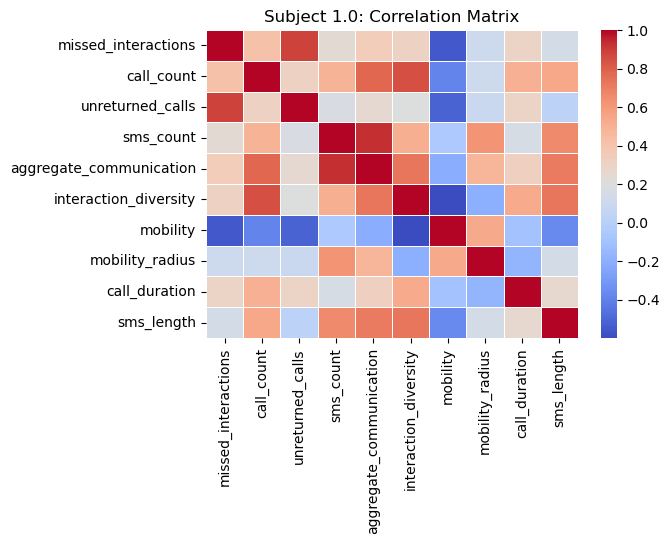

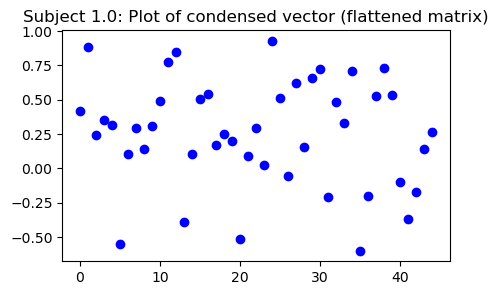

189 subs with symptom matrices
189 filled condensed arrays
Target cols for v1_week:
In df there are 238 subjects.


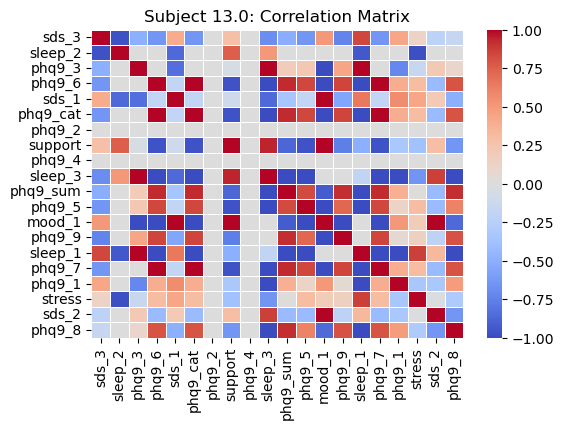

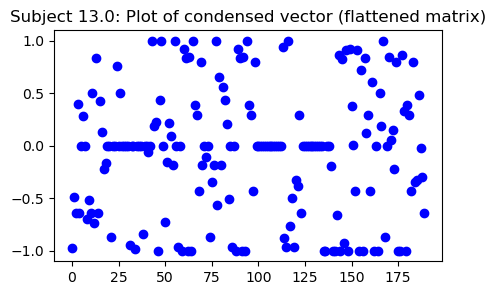

184 subs with symptom matrices
184 filled condensed arrays


DATAFRAME: v2_week
['phq2_2', 'sds_3', 'distance_walking', 'season_num_4.0', 'race_2.0', 'season_fall', 'marital_status_1.0', 'distance_walking_hr', 'race_0.0', 'distance_high_speed_transportation_hr', 'season_num_3.0', 'gender_1.0', 'sleep_2', 'season_summer', 'hours_stationary_nhw', 'month', 'phq9_3', 'came_to_work', 'phq9_6', 'phq2_sum', 'race_6.0', 'phq9_cat', 'sds_1', 'hours_accounted_for', 'distance_high_speed_transportation', 'phq9_2', 'distance_powered_vehicle', 'season_winter', 'support', 'hours_active_hr', 'phq9_4', 'phq9_sum', 'location_variance_hr', 'sleep_3', 'season_num_2.0', 'income_lastyear', 'phq9_5', 'hours_high_speed_transportation_hr', 'mood_1', 'hours_of_sleep_hr', 'phq2_1', 'phq9_9', 'race_7.0', 'location_variance', 'sleep_1', 'race_1.0', 'phq9_7', 'mhs_sum', 'hours_active', 'phq9_1', 'distance_active_hr', 'distance_active', 'hours_of_sleep', 'marital_status_2.0', 'hours_stationary', 'hours_high_speed_tr

/var/folders/fl/b24z_8kn4490x_bl0njv6fg00000gn/T/ipykernel_2047/3425606417.py:16: DtypeWarning: Columns (129) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_transformed.csv'))


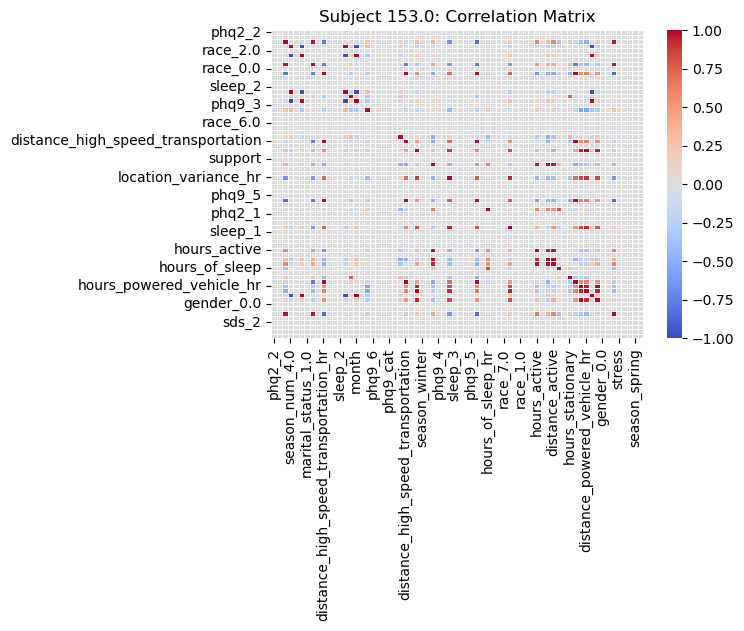

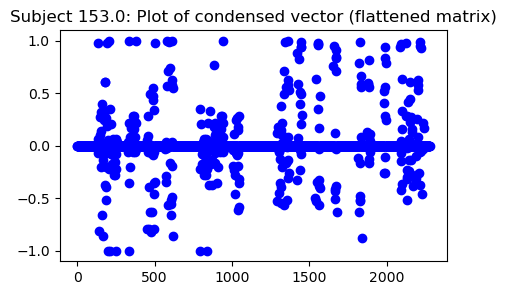

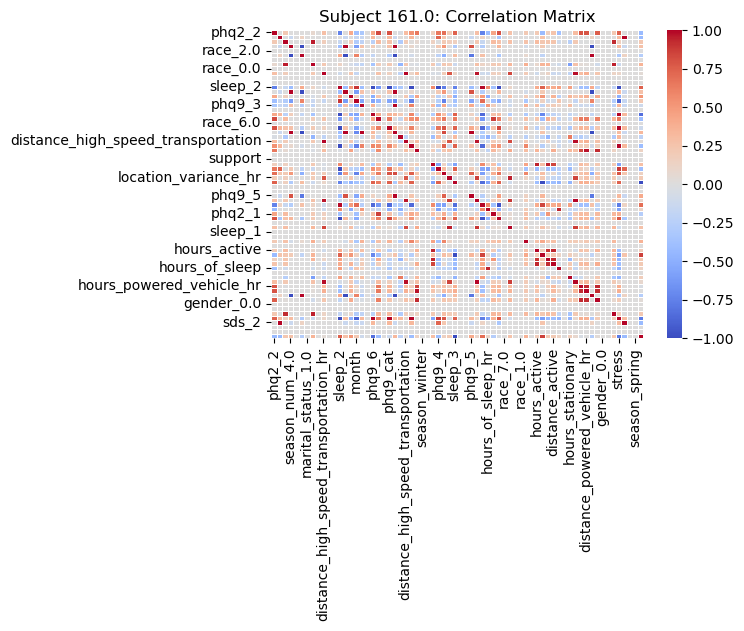

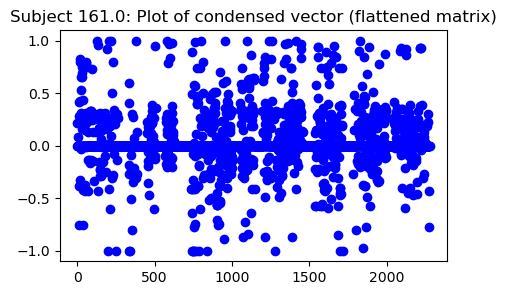

162 subs with symptom matrices
162 filled condensed arrays
Sensor cols for v2_week:
['came_to_work', 'hours_powered_vehicle_hr', 'precip_sum', 'hours_powered_vehicle', 'distance_powered_vehicle', 'distance_high_speed_transportation', 'hours_of_sleep', 'distance_active', 'location_variance', 'hours_active', 'distance_powered_vehicle_hr', 'dew_point_IQR', 'hours_high_speed_transportation_hr', 'distance_active_hr', 'cloud_cover_IQR', 'location_variance_hr', 'distance_high_speed_transportation_hr', 'hours_of_sleep_hr', 'hours_active_hr', 'dew_point_std', 'distance_walking_hr', 'hours_high_speed_transportation', 'distance_walking', 'dew_point_mean', 'humidity_mean', 'temp_mean', 'cloud_cover_mean', 'cloud_cover_median', 'humidity_std', 'dew_point_median', 'temp_std', 'temp_median', 'cloud_cover_std', 'temp_IQR', 'humidity_median', 'humidity_IQR']
In df there are 196 subjects.


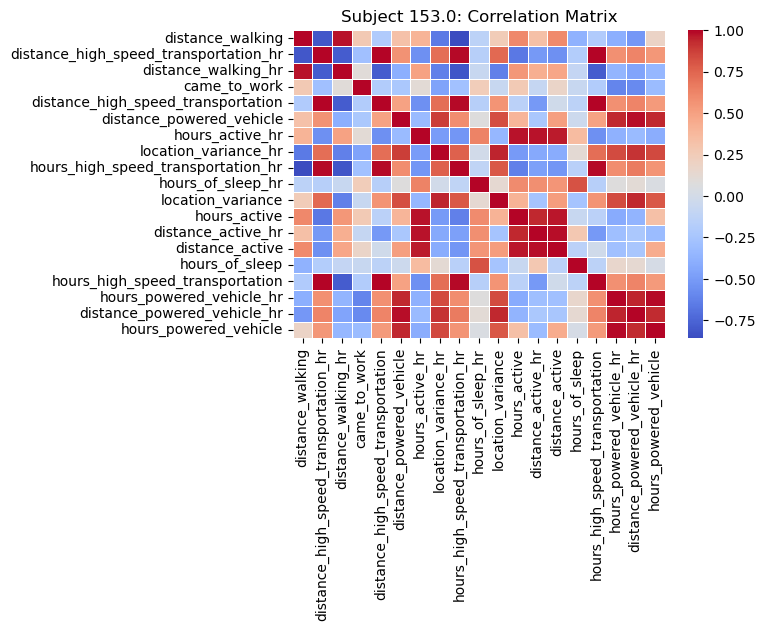

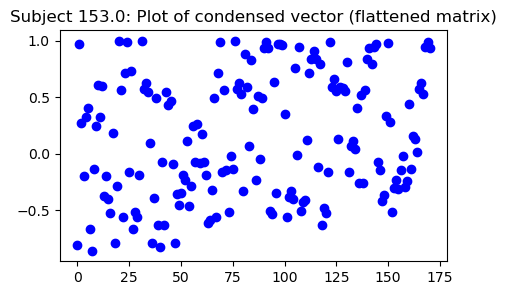

162 subs with symptom matrices
162 filled condensed arrays
Target cols for v2_week:
In df there are 196 subjects.


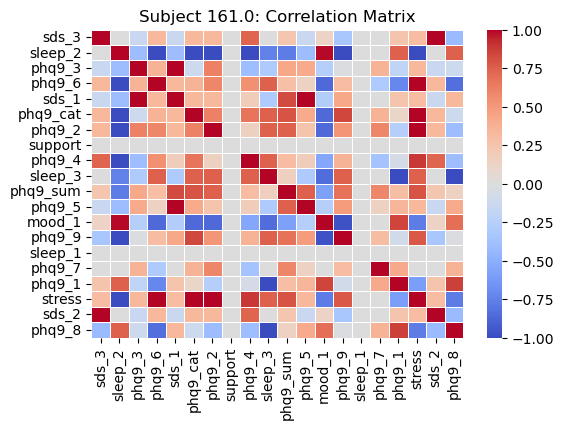

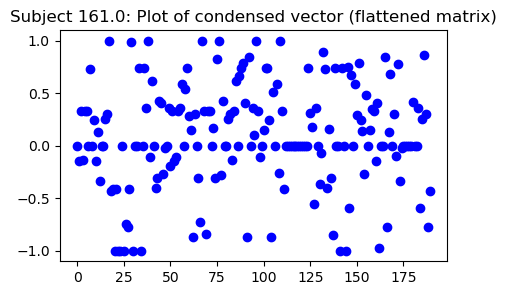

141 subs with symptom matrices
141 filled condensed arrays


In [ ]:

symptom_matrices_df_dict = {}
flattened_matrices_df_dict = {}
sensor_matrices_df_dict = {}
dailySurvey_matrices_df_dict = {}
weeklySurvey_matrices_df_dict = {}
flattened_sensor_df_dict = {}
flattened_target_df_dict = {}	

correlated_weather_cols = ['non-skew__humidity_mean', 'non-skew__humidity_median', 'non-skew__cloud_cover_mean', 'non-skew__cloud_cover_median']
weeklySurvey = phq9_cols+weekly_cols
dailySurvey = phq2_cols
sensor_cols = daily_cols_v1+daily_cols_v2

#### Take the average of each subject's symptom correlation and use it to make clusters of variables

# Create dicts of all subjects' correlation matrices
for name in df_names:
	print(f'\n\nDATAFRAME: {name}')

	df = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_transformed.csv'))
	df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
	
	# Take out outcome columns
	y_cols=['phq9_sum_start', 'start_depressed_binary', 'phq9_sum_6wks', '6wks_depressed_binary', 'depression_change_bin']
	df = df.drop(columns=[col for col in df.columns if any(item in col for item in y_cols)])

	# Take out baseline columns
	df = df.drop(columns=[col for col in df.columns if col in baseline_cols])

	# Make symptom/flattened dicts for all cols
	ignore_cols = [col for col in df.columns if col in id_columns or "_indicator" in col or "_bin" in col or "index" in col]
	ignore_cols.append('season')
	target_cols = [col for col in df.columns if "phq9" in col or 'phq2' in col]

	weather_cols_present = [col for col in df.columns if any(item in col for item in daily_v2_weather)]
	weather_cols_drop = [col for col in weather_cols_present if col not in correlated_weather_cols]
	ignore_cols += weather_cols_drop

	keep_columns = list(set(df.columns.to_list()) - set(ignore_cols))
	print(keep_columns)
	print(f"All cols for {name}:")
	symptom_matrix_dict, flattened_matrix_dict = fs.make_symptom_matrices(df.select_dtypes(include=('int64','float64')), ignore_cols, num_to_plot=2)
	

	# Assign dicts to nested dict
	symptom_matrices_df_dict[name] = symptom_matrix_dict
	flattened_matrices_df_dict[name] = flattened_matrix_dict


	# Make separate symptom/flattened dicts for target cols vs. sensor cols
	if 'week' in name:
		print(f"Sensor cols for {name}:")
		sensor_cols_present = [col for col in df.columns if any(item in col for item in sensor_cols)]
		print(sensor_cols_present)
		nonsensor_cols = [col for col in df.columns if col not in sensor_cols_present]
		sensor_matrices_dict, flattened_sensor_dict = fs.make_symptom_matrices(df, ignore_cols+nonsensor_cols, num_to_plot=1)
			
		print(f"Weekly Survey cols for {name}:")
		weeklySurvey_present = [col for col in df.columns if col in weeklySurvey]
		weeklySurvey_df = df.copy()[[col for col in df.columns if col in weeklySurvey_present]]
		weeklySurvey_matrices_df_dict, flattened_weeklySurvey_dict = fs.make_symptom_matrices(weeklySurvey_df, ignore_cols, num_to_plot=1)

		print(f"Daily Survey cols for {name}:")
		dailySurvey_present = [col for col in df.columns if col in dailySurvey]
		dailySurvey_df = df.copy()[[col for col in df.columns if col in dailySurvey_present]]
		dailySurvey_matrices_df_dict, flattened_dailySurvey_dict = fs.make_symptom_matrices(dailySurvey_df, ignore_cols, num_to_plot=1)


	if 'day' in name:
		print(f"Sensor cols for {name}:")
		target_cols = phq2_cols+weekly_cols
		sensor_cols = [col for col in df.columns if any(item in col for item in daily_cols_v1+daily_cols_v2)]
		print(sensor_cols)
		nonsensor_cols = [col for col in df.columns if col not in sensor_cols]
		sensor_matrices_dict, flattened_sensor_dict = fs.make_symptom_matrices(df, ignore_cols+nonsensor_cols, num_to_plot=1)
		target_df = df.copy().drop(columns=[col for col in df.columns if col not in target_cols and 'num_id' not in col])
		print(f"Target cols for {name}:")
		target_matrices_dict, flattened_target_dict = fs.make_symptom_matrices(target_df, ignore_cols, num_to_plot=1)

	#Assign sensor/target dicts to nested dict
	sensor_matrices_df_dict[name] = sensor_matrices_dict
	target_matrices_df_dict[name] = target_matrices_dict
	flattened_sensor_df_dict[name] = flattened_sensor_dict
	flattened_target_df_dict[name] = flattened_target_dict




In [40]:
sensor_matrices_dict[153.0]

,distance_walking_hr,distance_high_speed_transportation_hr,came_to_work,distance_high_speed_transportation,distance_walking,hours_high_speed_transportation,hours_of_sleep_hr,hours_of_sleep,hours_high_speed_transportation_hr
distance_walking_hr,1.000000,-0.790424,0.097084,-0.790424,0.974258,-0.790424,-0.071470,-0.088492,-0.820088
distance_high_speed_transportation_hr,-0.790424,1.000000,-0.284268,1.000000,-0.809904,1.000000,-0.163427,-0.189344,0.990709
came_to_work,0.097084,-0.284268,1.000000,-0.190885,0.273342,-0.190885,0.245036,-0.070448,-0.281626
distance_high_speed_transportation,-0.790424,1.000000,-0.190885,1.000000,-0.198588,1.000000,-0.163427,-0.136332,0.990709
distance_walking,0.974258,-0.809904,0.273342,-0.198588,1.000000,-0.198588,-0.135601,-0.374816,-0.856946
hours_high_speed_transportation,-0.790424,1.000000,-0.190885,1.000000,-0.198588,1.000000,-0.163427,-0.136332,0.990709
hours_of_sleep_hr,-0.071470,-0.163427,0.245036,-0.163427,-0.135601,-0.163427,1.000000,0.813112,-0.112377
hours_of_sleep,-0.088492,-0.189344,-0.070448,-0.136332,-0.374816,-0.136332,0.813112,1.000000,-0.159461
hours_high_speed_transportation_hr,-0.820088,0.990709,-0.281626,0.990709,-0.856946,0.990709,-0.112377,-0.159461,1.000000


/Users/demo/Library/CloudStorage/Box-Box/Holmes_lab_kaley/motif_proj/brighten_analysis/scripts/feature_selection.py:374: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


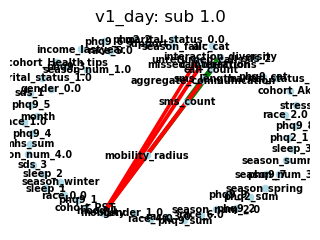

/Users/demo/Library/CloudStorage/Box-Box/Holmes_lab_kaley/motif_proj/brighten_analysis/scripts/feature_selection.py:374: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


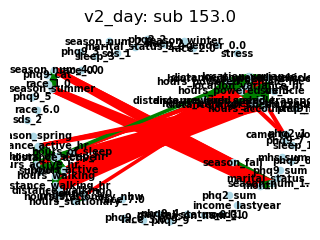

/Users/demo/Library/CloudStorage/Box-Box/Holmes_lab_kaley/motif_proj/brighten_analysis/scripts/feature_selection.py:374: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


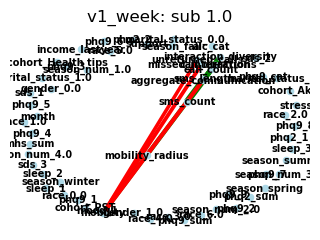

/Users/demo/Library/CloudStorage/Box-Box/Holmes_lab_kaley/motif_proj/brighten_analysis/scripts/feature_selection.py:374: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


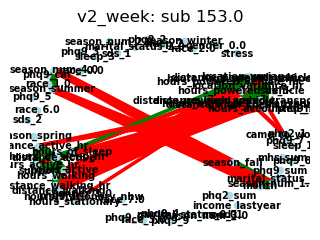

In [8]:
# Plot a few symptom matrices
for name, df_dict in symptom_matrices_df_dict.items():
	count=0
	for sub, corr_matrix in df_dict.items():
		if count<1:
			fs.plot_network(corr_matrix, title=f'{name}: sub {sub}')
			count=+1

# Plot some hierarchical agglomerative clustering for the average within-participant symptom matrix correlations 

## First just daily

v1_day
(10, 10) variables included


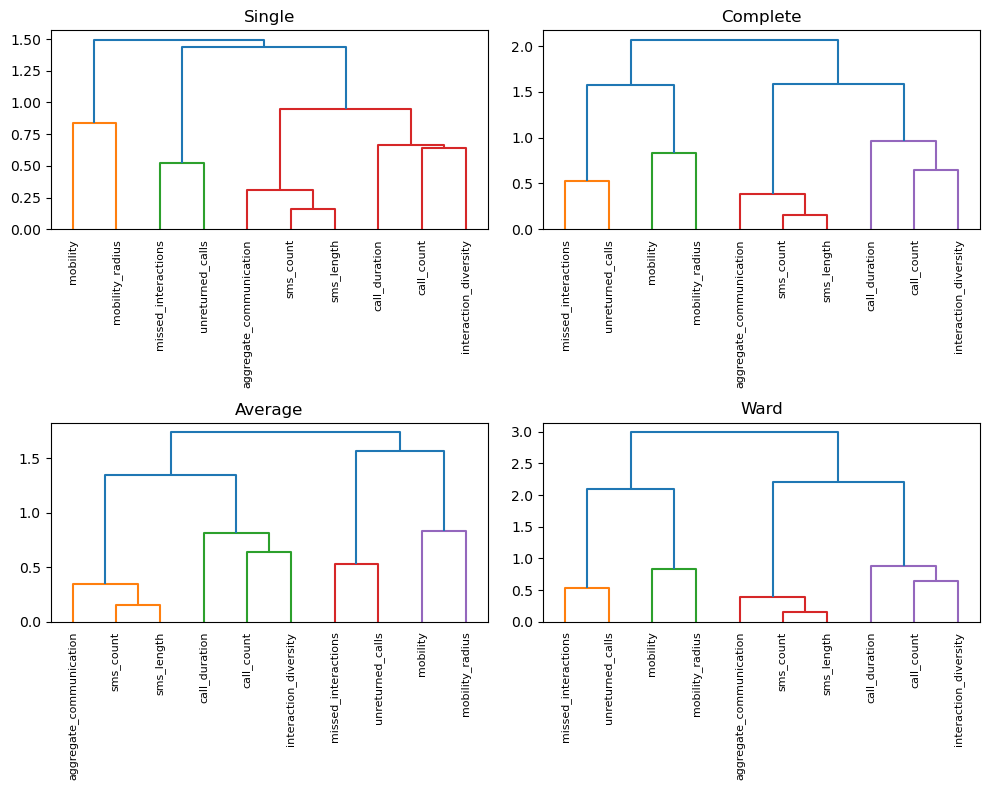

v2_day
(19, 19) variables included


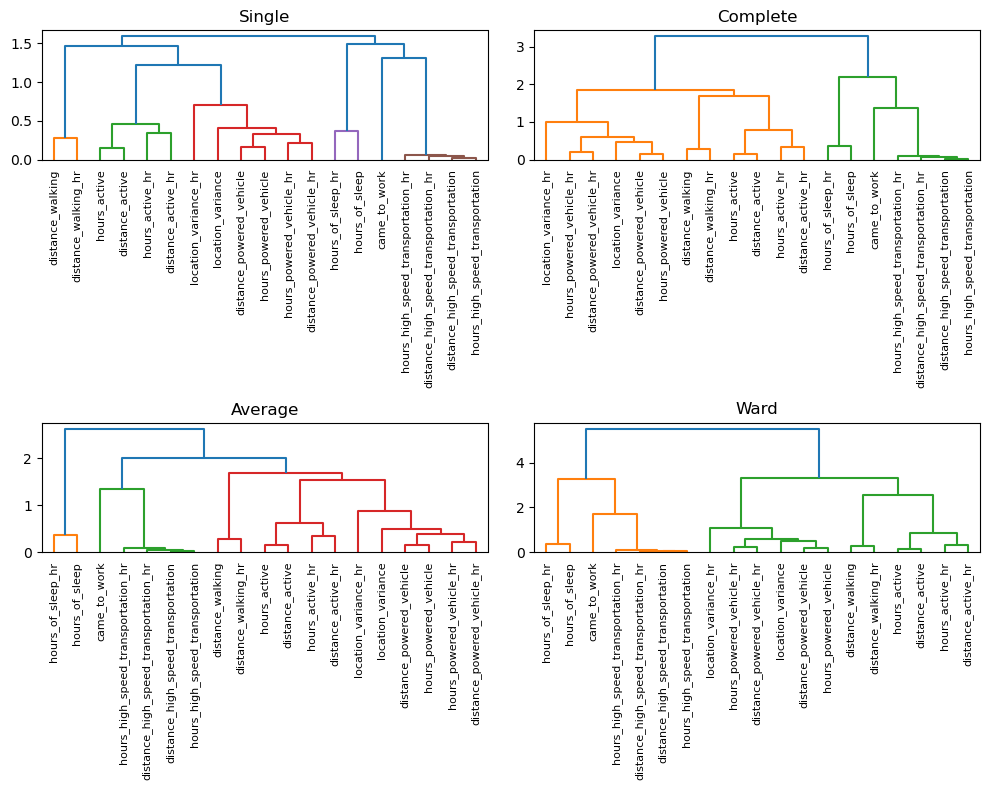

v1_week
(10, 10) variables included


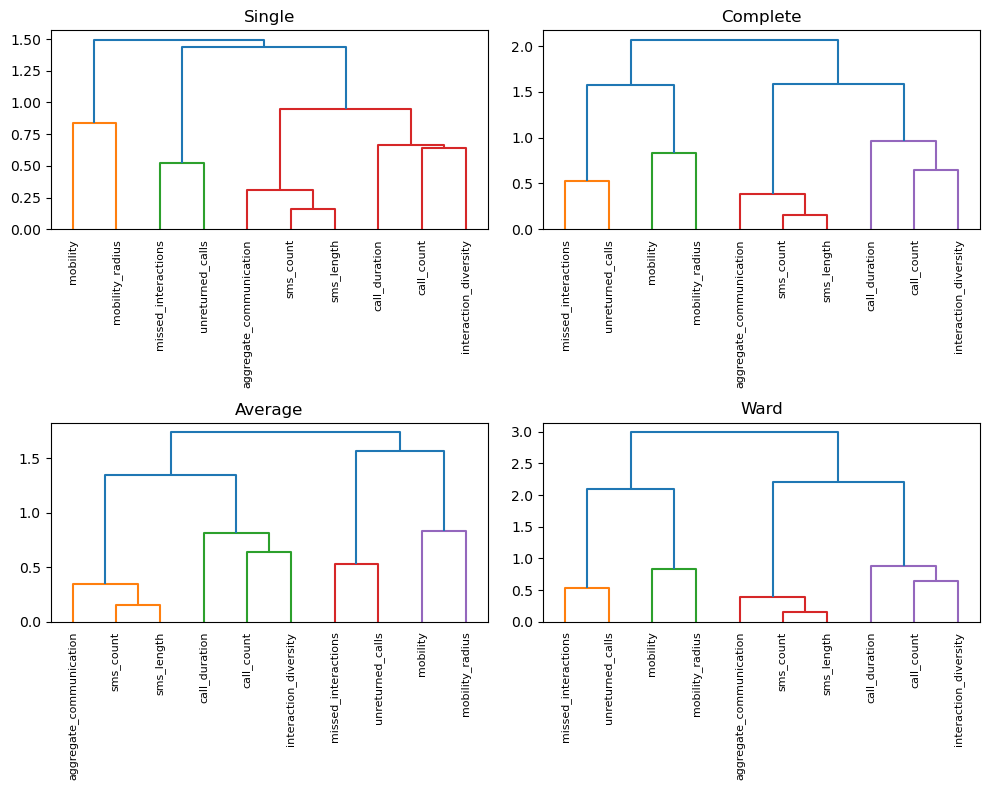

v2_week
(19, 19) variables included


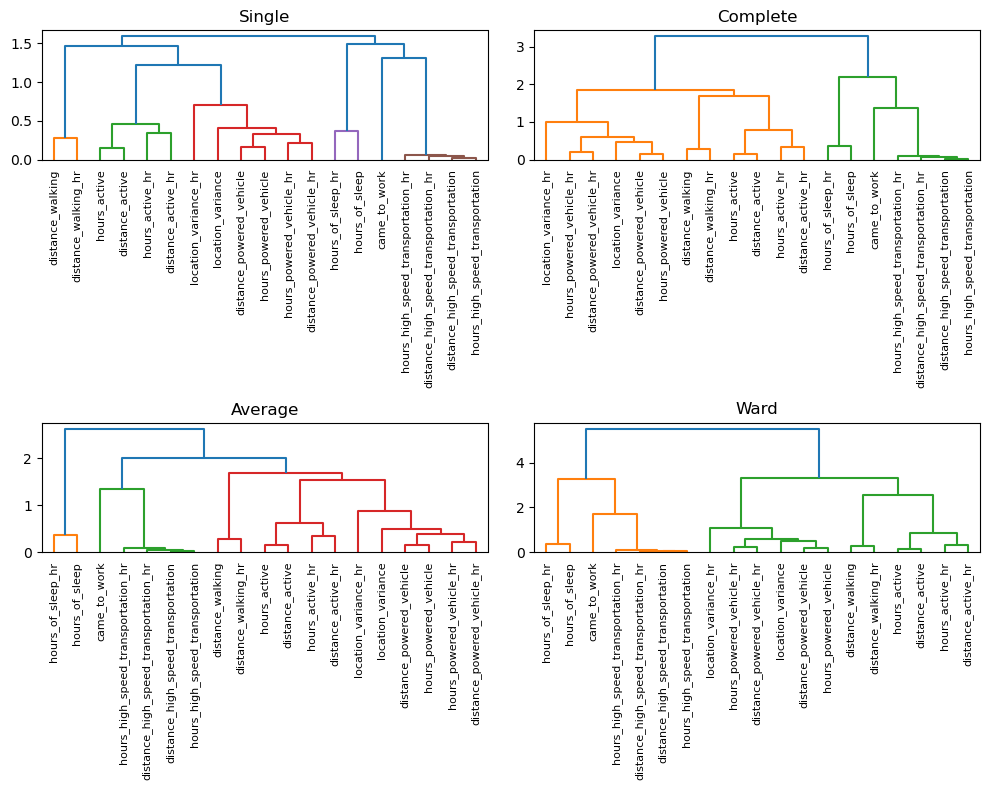

In [10]:
## Plot options
for name, df in sensor_matrices_df_dict.items():
	avg_matrix = fs.average_matrix(df)
	fs.plot_hier_agg(avg_matrix, df[list(df.keys())[0]].index, is_dict=False, group_title=f'{name}') # 3, ward


## Now weekly

v1_day
(23, 23) variables included


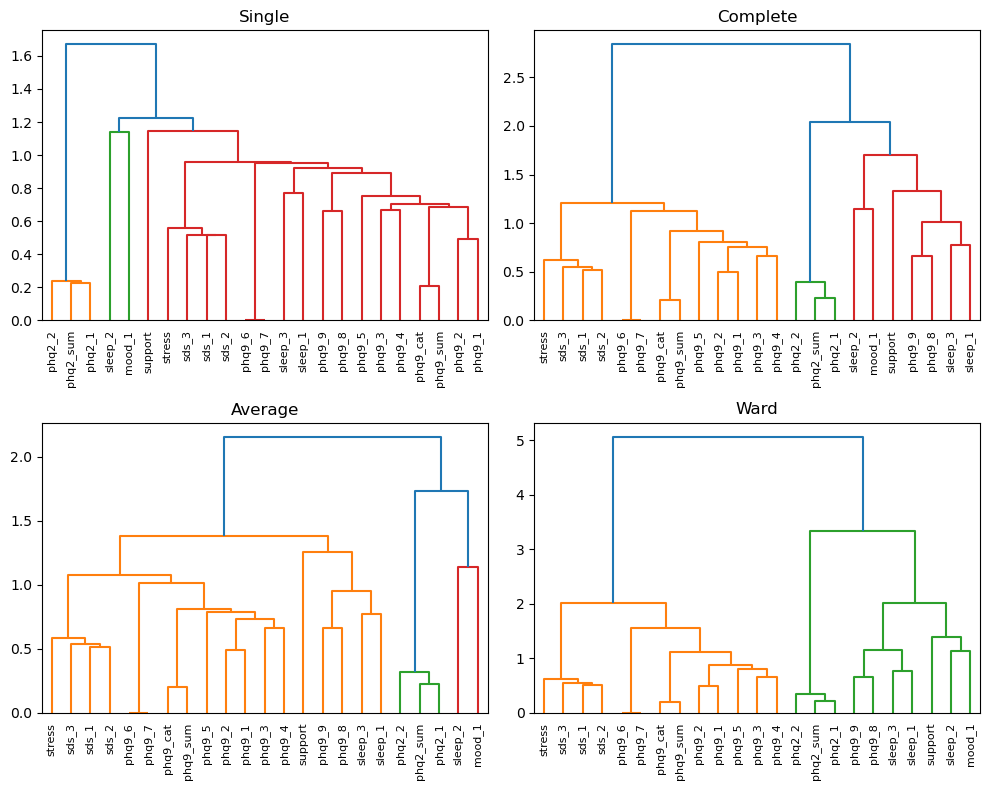

v2_day
(23, 23) variables included


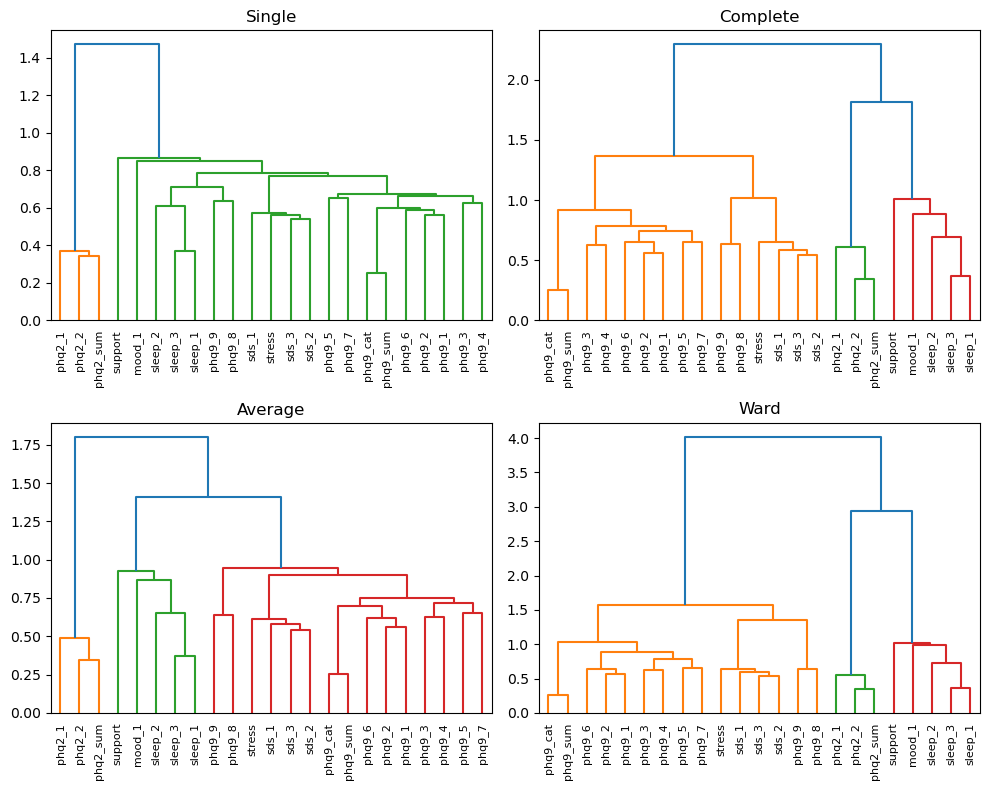

v1_week
(20, 20) variables included


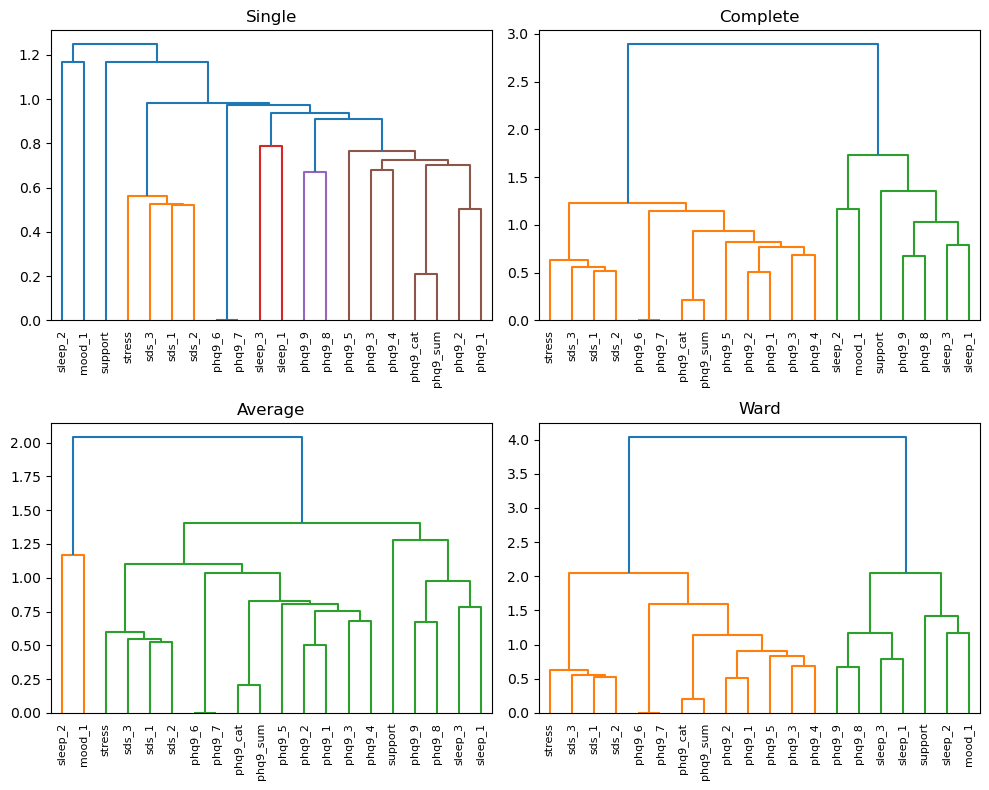

v2_week
(20, 20) variables included


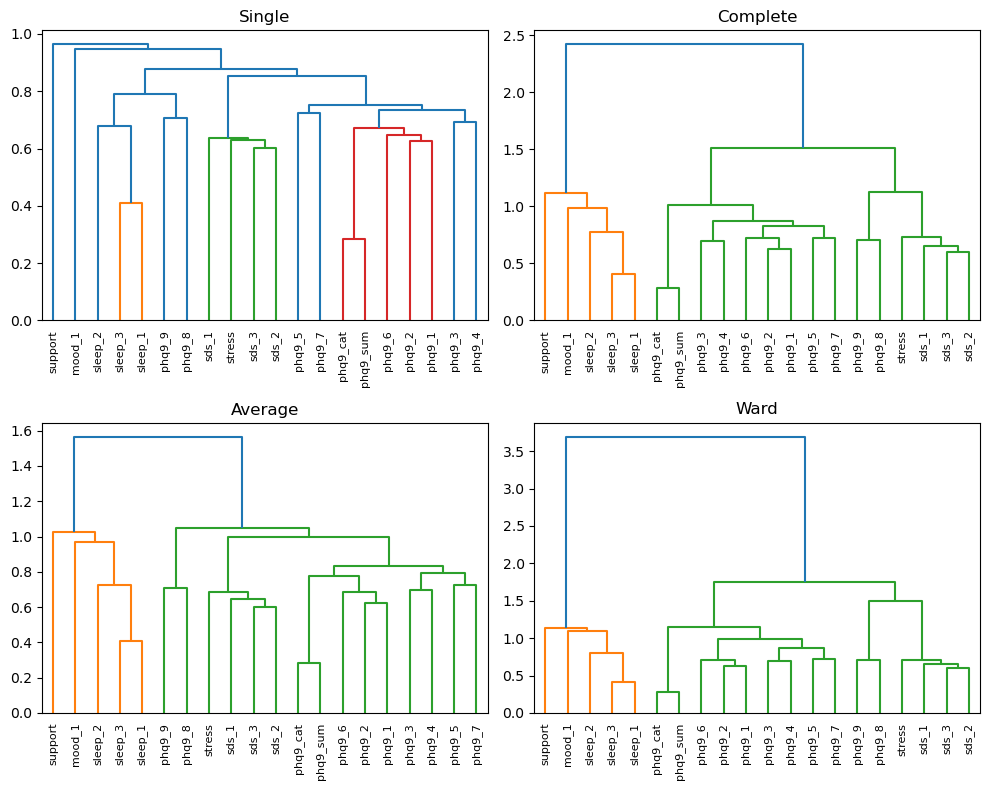

In [11]:
## Plot options
for name, df in target_matrices_df_dict.items():
	avg_matrix = fs.average_matrix(df)
	fs.plot_hier_agg(avg_matrix, df[list(df.keys())[0]].index, is_dict=False, group_title=f'{name}') # 3, ward


# Do PCA for sensor columns

In [ ]:
################# Create cluster_dict of Variables + Cluster Labels ############
# Fill in n clusters + linkage type

clust_dict = {}
# clust_dict['v1_day'] = v1_day_clust_dict
for name, dictionary in sensor_matrices_df_dict.items():
	avg_matrix = fs.average_matrix(dictionary)
	if 'v1_day' in name:
		clust_dict[name] = fs.hier_agg_clustering(avg_matrix, dictionary[list(dictionary.keys())[0]].index, n_clusters=5, linkage='complete', is_dict=False)
	elif 'v2_day' in name:
		clust_dict[name] = fs.hier_agg_clustering(avg_matrix, dictionary[list(dictionary.keys())[0]].index, n_clusters=7, linkage='single', is_dict=False)
	elif 'v1_week' in name:
		clust_dict[name] = fs.hier_agg_clustering(avg_matrix, dictionary[list(dictionary.keys())[0]].index, n_clusters=6, linkage='complete', is_dict=False)
	elif 'v2_week' in name:
	   clust_dict[name] = fs.hier_agg_clustering(avg_matrix, dictionary[list(dictionary.keys())[0]].index, n_clusters=7, linkage='single', is_dict=False)

In [46]:
################# Create df_pca of Variables + 1st PC of clusters Labels ############
importlib.reload(fs)
dfs_pca = {}
dfs_pca_dict = {}
for name in df_names:
	df = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_transformed.csv'))	
	
	print(f'\nFor {name}')
	dfs_pca[name], dfs_pca_dict[name] = fs.pca_on_clusters(df, clust_dict[name], n_clusters=9, wide=False) #n_clusters = number shown, so choose max



For v1_day
Cols for cluster 0: ['call_duration', 'call_count', 'aggregate_communication', 'sms_count', 'sms_length']
Cols for cluster 1: ['mobility', 'mobility_radius', 'support', 'mood_1', 'sleep_2', 'alc_cat', 'income_lastyear', 'month']
Cols for cluster 2: ['phq2_1', 'phq2_2', 'phq2_sum']
Cols for cluster 3: ['sds_2', 'sleep_1', 'sds_3', 'sleep_3', 'stress', 'sds_1']
Cols for cluster 4: ['unreturned_calls', 'missed_interactions']
Skipping cluster 5: No variables assigned.
Skipping cluster 6: No variables assigned.
Skipping cluster 7: No variables assigned.
Skipping cluster 8: No variables assigned.

For v2_day
Cols for cluster 0: ['hours_stationary', 'hours_stationary_nhw']
Cols for cluster 1: ['distance_walking_hr', 'distance_walking', 'hours_walking']
Cols for cluster 2: ['came_to_work', 'support', 'sds_2', 'sleep_1', 'sds_3', 'sleep_3', 'stress', 'sds_1', 'mood_1', 'sleep_2', 'income_lastyear', 'month']
Cols for cluster 3: ['hours_of_sleep_hr', 'hours_of_sleep']
Cols for cluster

/var/folders/fl/b24z_8kn4490x_bl0njv6fg00000gn/T/ipykernel_55225/3960856448.py:6: DtypeWarning: Columns (139) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_transformed.csv'))
/var/folders/fl/b24z_8kn4490x_bl0njv6fg00000gn/T/ipykernel_55225/3960856448.py:6: DtypeWarning: Columns (139) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_transformed.csv'))


In [ ]:
# ===============================
# v1_day cluster naming
# ===============================
dfs_pca_dict['v1_day'][0]['name'] = 'pc_calls_texts'            # call_duration, call_count, aggregate_communication, sms_count, sms_length
dfs_pca_dict['v1_day'][1]['name'] = 'pc_mobility_support_mood'  # mobility, mobility_radius, support, mood_1, sleep_2, alc_cat, income_lastyear, month
dfs_pca_dict['v1_day'][2]['name'] = 'pc_phq2'                   # phq2_1, phq2_2, phq2_sum
dfs_pca_dict['v1_day'][3]['name'] = 'pc_sds_sleep_stress'       # sds_2, sleep_1, sds_3, sleep_3, stress, sds_1
dfs_pca_dict['v1_day'][4]['name'] = 'pc_missed_calls'           # unreturned_calls, missed_interactions
# clusters 5–8 skipped (no variables)


# ===============================
# v2_day cluster naming
# ===============================
dfs_pca_dict['v2_day'][0]['name'] = 'pc_stationary'             # hours_stationary, hours_stationary_nhw
dfs_pca_dict['v2_day'][1]['name'] = 'pc_walking'                # distance_walking_hr, distance_walking, hours_walking
dfs_pca_dict['v2_day'][2]['name'] = 'pc_support_sleep_stress'   # came_to_work, support, sds_2, sleep_1, sds_3, sleep_3, stress, sds_1, mood_1, sleep_2, income_lastyear, month
dfs_pca_dict['v2_day'][3]['name'] = 'pc_sleep_hours'            # hours_of_sleep_hr, hours_of_sleep
dfs_pca_dict['v2_day'][4]['name'] = 'pc_highspeed_transport'    # distance_high_speed_transportation_hr, distance_high_speed_transportation, hours_high_speed_transportation, hours_high_speed_transportation_hr
dfs_pca_dict['v2_day'][5]['name'] = 'pc_phq2'                   # phq2_1, phq2_2, phq2_sum
dfs_pca_dict['v2_day'][6]['name'] = 'pc_time_accounted'         # hours_accounted_for
# clusters 7–8 skipped (no variables)


# ===============================
# v1_week cluster naming
# ===============================
dfs_pca_dict['v1_week'][0]['name'] = 'pc_mobility_support_mood' # mobility, mobility_radius, support, mood_1, sleep_2, alc_cat, income_lastyear, month
dfs_pca_dict['v1_week'][1]['name'] = 'pc_sds_sleep_stress'      # sds_2, sleep_1, sds_3, sleep_3, stress, sds_1
dfs_pca_dict['v1_week'][2]['name'] = 'pc_phq2'                  # phq2_1, phq2_2, phq2_sum
dfs_pca_dict['v1_week'][3]['name'] = 'pc_calls'                 # call_duration, call_count
dfs_pca_dict['v1_week'][4]['name'] = 'pc_missed_calls'          # unreturned_calls, missed_interactions
dfs_pca_dict['v1_week'][5]['name'] = 'pc_texts'                 # aggregate_communication, sms_count, sms_length
# clusters 6–8 skipped (no variables)


# ===============================
# v2_week cluster naming
# ===============================
dfs_pca_dict['v2_week'][0]['name'] = 'pc_stationary'            # hours_stationary, hours_stationary_nhw
dfs_pca_dict['v2_week'][1]['name'] = 'pc_phq2'                  # phq2_1, phq2_2, phq2_sum
dfs_pca_dict['v2_week'][2]['name'] = 'pc_support_sleep_stress'  # came_to_work, support, sds_2, sleep_1, sds_3, sleep_3, stress, sds_1, mood_1, sleep_2, income_lastyear, month
dfs_pca_dict['v2_week'][3]['name'] = 'pc_walking'               # distance_walking_hr, distance_walking, hours_walking
dfs_pca_dict['v2_week'][4]['name'] = 'pc_highspeed_transport'   # distance_high_speed_transportation_hr, distance_high_speed_transportation, hours_high_speed_transportation, hours_high_speed_transportation_hr
dfs_pca_dict['v2_week'][5]['name'] = 'pc_sleep_hours'           # hours_of_sleep_hr, hours_of_sleep
dfs_pca_dict['v2_week'][6]['name'] = 'pc_time_accounted'        # hours_accounted_for
# clusters 7–8 skipped (no variables)

importlib.reload(fs)
dfs_pca = {}
for name in df_names:
	df_scaled = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_transformed.csv'))
	dfs_pca[name] = fs.merge_df_via_cluster_pca_dict(df_scaled, dfs_pca_dict[name], on_columns=['num_id','day'])
	dfs_pca[name].to_csv(os.path.join(brighten_dir, f'{name}_trainval_sensor_pca.csv'), index=False)
	print(f'Saved {name} PCA df to {name}_trainval_sensor_pca.csv')




Saved v1_day PCA df to v1_day_trainval_pca.csv
Saved v2_day PCA df to v2_day_trainval_pca.csv
Saved v1_week PCA df to v1_week_trainval_pca.csv
Saved v2_week PCA df to v2_week_trainval_pca.csv


/var/folders/fl/b24z_8kn4490x_bl0njv6fg00000gn/T/ipykernel_55225/3767339898.py:52: DtypeWarning: Columns (139) have mixed types. Specify dtype option on import or set low_memory=False.
  df_scaled = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_transformed.csv'))
/var/folders/fl/b24z_8kn4490x_bl0njv6fg00000gn/T/ipykernel_55225/3767339898.py:52: DtypeWarning: Columns (139) have mixed types. Specify dtype option on import or set low_memory=False.
  df_scaled = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_transformed.csv'))


/Users/demo/Library/CloudStorage/Box-Box/Holmes_lab_kaley/motif_proj/brighten_analysis/scripts/feature_selection.py:374: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


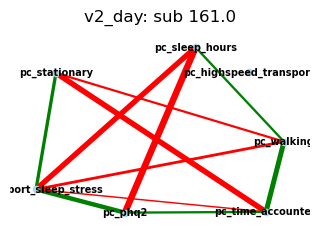

/Users/demo/Library/CloudStorage/Box-Box/Holmes_lab_kaley/motif_proj/brighten_analysis/scripts/feature_selection.py:374: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


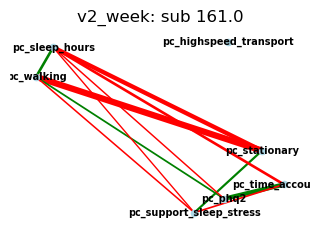

In [ ]:
############ Plot subjects' individual networks of PCs ############
# Predefine fixed positions for nodes
fixed_positions_v1_day = {
    'pc_mobility': (1, 1),
    'pc_calls': (1, 2),
    'pc_sms': (2, 1),
    'pc_phq2': (1, 3),
    'pc_phq2_missing': (2, 2)
}

fixed_positions_v1_week = {
    'pc_missing': (1, 2),
    'pc_mobility': (1, 1),
    'pc_phq2': (2, 1),
    'pc_phq9': (1, 3),
    'pc_calls': (2, 2)
}




for name, df in dfs_pca.items():
	count = 0
	
	cols=[col for col in df.columns.to_list() if 'pc_' in col]
	for sub, sub_df in df.groupby('num_id'):
		corr_matrix = sub_df[cols].corr()
		if count<10:
			fs.plot_network(corr_matrix, title=f'{name}: sub {sub}', threshold=0.2, fixed_positions=None)
			count+=1


In [ ]:
for name in df_names:
    df = pd.read_csv(os.path.join(brighten_dir, f'{name}_pca.csv'))
    print(f'\n\nFor {name}:')
    numeric_cols = [col for col in df.columns.to_list() if 'pc_' in col]
    sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm", center=0)
    plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupShuffleSplit

for name in df_names:
    data_df = pd.read_csv(os.path.join(brighten_dir, f'{name}_pca.csv'))
    data_df = data_df.dropna()
    if not data_df.empty:
        if 'phq9_sum' in data_df.columns:
            target_var = 'phq9_sum'
        else:
            target_var = 'phq2_sum'
        print(f"\n\nFOR {name}, target_var: {target_var}")

        X = data_df.drop(columns=[col for col in data_df.columns if 'phq9' in col or 'phq2' in col]).copy()
        y = data_df[target_var].copy()

        gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
        groups = data_df['num_id'] # groups variable is based on num_id, so that no subjects are in train and test etc, 
        trainval_idx, test_idx = next(gss.split(X, y, groups=groups))

        # Get train/test sets
        X_trainval, X_test = X.iloc[trainval_idx], X.iloc[test_idx]
        y_trainval, y_test = y.iloc[trainval_idx], y.iloc[test_idx]

        gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        groups_trainval = groups.iloc[trainval_idx]  # redefining groups to only include subs in traintest df
        train_idx, val_idx = next(gss.split(X_trainval, y_trainval, groups=groups_trainval))

        # Get train/test sets
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        X_test.to_csv(os.path.join(brighten_dir, f'{name}_pca_X_test.csv'), index=False)
        y_test.to_csv(os.path.join(brighten_dir, f'{name}_pca_y_test.csv'), index=False)
        X_train.to_csv(os.path.join(brighten_dir, f'{name}_pca_X_train.csv'), index=False)
        y_train.to_csv(os.path.join(brighten_dir, f'{name}_pca_y_train.csv'), index=False)
        X_val.to_csv(os.path.join(brighten_dir, f'{name}_pca_X_val.csv'), index=False)
        y_val.to_csv(os.path.join(brighten_dir, f'{name}_pca_y_val.csv'), index=False)


        # # Create hisogram for target value
        # sns.histplot(y_val, bins=10)
        # plt.title(f'y val for {name}, target: {target_var}')
        # plt.show()

        # Create hisogram for target value
        sns.histplot(y_train, bins=10)
        plt.title(f'y train for {name}, target: {target_var}')
        plt.show()

        # Create hisogram for target value
        sns.histplot(y_test, bins=10)
        plt.title(f'y test for {name}, target: {target_var}')
        plt.show()


# NBS using each subject's symptom/sensor structure
T test https://www.youtube.com/watch?v=VekJxtk4BYM 

Needs normal distribution of the metric variables-- test for normal distribution of each corr value

also the variance between my two groups must be approximately equal -- levene's test

In [ ]:
#num_id	change_sum	week	change_binary	phq9_mean	phq9_bin
#v1_phq9_sum_change.csv

# SENSOR AND SURVEY 
# Network based statistics for high phq9 vs. low phq9 -- OVER WHOLE STUDY
import bct 
from bct import nbs
from scipy import stats

significance_level = 0.05
columns=['num_id', 'phq9_sum_start', 'start_depressed_binary', 'phq9_sum_6wks', '6wks_depressed_binary', 'depression_change_bin']

for name in ['v1_day','v2_day']:
	print(f'############################### {name} ###############################')
	data_df = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_transformed.csv'))
	depressed = data_df[data_df['start_depressed_binary']==1]['num_id']

	print(f'There are {len(depressed)} subs in the depressed group')
	depressed_present = [sub for sub in depressed if sub in sensor_matrices_df_dict[name]]
	print(f'There are {len(depressed_present)} subs present from the depressed group')
	X = {key: sensor_matrices_df_dict[name][key] for key in depressed_present}
	x_arr = np.stack([df.values for df in X.values()], axis=-1)
	print(f'x_arr shape {x_arr.shape}')
		
	nondepressed = data_df[data_df['start_depressed_binary']==0]['num_id']
	print(f'There are {len(nondepressed)} subs in the nondepressed group')
	nondepressed_present = [sub for sub in nondepressed if sub in sensor_matrices_df_dict[name]]
	print(f'There are {len(nondepressed_present)} subs present from the nondepressed group')
	y = {key: sensor_matrices_df_dict[name][key] for key in nondepressed_present}
	y_arr = np.stack([df.values for df in y.values()], axis=-1)
	print(f'y_arr shape {y_arr.shape}')

	degf = len(X) + len(y) - 2
	print(f'The degrees of freedom are: {degf}')

	t_thresh = stats.t.ppf(1-significance_level, degf)
	print(f'The critical t value is {round(t_thresh, 2)}')

	pval, adj, null = nbs.nbs_bct(x_arr, y_arr, thresh=t_thresh, verbose=False)
	print(pval)
	# Convert adj to boolean mask
	mask = adj.astype(bool)
	component_cols = y[next(iter(y))].loc[:, mask]
	print(component_cols.columns.to_list())


############################### v1_day ###############################
There are 3607 subs in the depressed group
There are 3593 subs present from the depressed group
x_arr shape (24, 24, 51)
There are 9528 subs in the nondepressed group
There are 9493 subs present from the nondepressed group
y_arr shape (24, 24, 132)
The degrees of freedom are: 181
The critical t value is 1.65
max component size is 27
estimating null distribution with 1000 permutations
permutation 0 of 1000.  p-value so far is 0.000
permutation 100 of 1000.  p-value so far is 0.248
permutation 200 of 1000.  p-value so far is 0.254
permutation 300 of 1000.  p-value so far is 0.299
permutation 400 of 1000.  p-value so far is 0.307
permutation 500 of 1000.  p-value so far is 0.311
permutation 600 of 1000.  p-value so far is 0.311
permutation 700 of 1000.  p-value so far is 0.304
permutation 800 of 1000.  p-value so far is 0.301
permutation 900 of 1000.  p-value so far is 0.302
permutation 999 of 1000.  p-value so far is 

/var/folders/fl/b24z_8kn4490x_bl0njv6fg00000gn/T/ipykernel_55225/974626252.py:15: DtypeWarning: Columns (139) have mixed types. Specify dtype option on import or set low_memory=False.
  data_df = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_transformed.csv'))


permutation 100 of 1000.  p-value so far is 0.040
permutation 200 of 1000.  p-value so far is 0.035
permutation 300 of 1000.  p-value so far is 0.033
permutation 400 of 1000.  p-value so far is 0.032
permutation 500 of 1000.  p-value so far is 0.038
permutation 600 of 1000.  p-value so far is 0.040
permutation 700 of 1000.  p-value so far is 0.041
permutation 800 of 1000.  p-value so far is 0.041
permutation 900 of 1000.  p-value so far is 0.040
permutation 999 of 1000.  p-value so far is 0.039
[0.039]
['sds_1', 'sds_1', 'sds_1', 'came_to_work', 'came_to_work', 'came_to_work', 'distance_high_speed_transportation_hr', 'distance_high_speed_transportation_hr', 'distance_high_speed_transportation_hr', 'sds_2', 'sds_2', 'sds_2', 'sds_2', 'sds_2', 'sds_2', 'hours_high_speed_transportation', 'hours_high_speed_transportation', 'hours_high_speed_transportation', 'hours_high_speed_transportation', 'hours_of_sleep', 'hours_of_sleep', 'hours_of_sleep', 'hours_walking', 'hours_walking', 'hours_walk

In [ ]:
#num_id	change_sum	week	change_binary	phq9_mean	phq9_bin
#v1_phq9_sum_change.csv

# SENSOR AND SURVEY 
# Network based statistics for high phq9 vs. low phq9 -- OVER WHOLE STUDY
import bct 
from bct import nbs
from scipy import stats

significance_level = 0.05
columns=['num_id', 'phq9_sum_start', 'start_depressed_binary', 'phq9_sum_6wks', '6wks_depressed_binary', 'depression_change_bin']

for name in ['v1_day','v2_day']:
	print(f'############################### {name} ###############################')
	data_df = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_transformed.csv'))
	depressed = data_df[data_df['6wks_depressed_binary']==1]['num_id']

	print(f'There are {len(depressed)} subs in the depressed group')
	depressed_present = [sub for sub in depressed if sub in sensor_matrices_df_dict[name]]
	print(f'There are {len(depressed_present)} subs present from the depressed group')
	X = {key: sensor_matrices_df_dict[name][key] for key in depressed_present}
	x_arr = np.stack([df.values for df in X.values()], axis=-1)
	print(f'x_arr shape {x_arr.shape}')
		
	nondepressed = data_df[data_df['6wks_depressed_binary']==0]['num_id']
	print(f'There are {len(nondepressed)} subs in the nondepressed group')
	nondepressed_present = [sub for sub in nondepressed if sub in sensor_matrices_df_dict[name]]
	print(f'There are {len(nondepressed_present)} subs present from the nondepressed group')
	y = {key: sensor_matrices_df_dict[name][key] for key in nondepressed_present}
	y_arr = np.stack([df.values for df in y.values()], axis=-1)
	print(f'y_arr shape {y_arr.shape}')

	degf = len(X) + len(y) - 2
	print(f'The degrees of freedom are: {degf}')

	t_thresh = stats.t.ppf(1-significance_level, degf)
	print(f'The critical t value is {round(t_thresh, 2)}')

	pval, adj, null = nbs.nbs_bct(x_arr, y_arr, thresh=t_thresh, verbose=False)
	print(pval)
	# Convert adj to boolean mask
	mask = adj.astype(bool)
	component_cols = y[next(iter(y))].loc[:, mask]
	print(component_cols.columns.to_list())


############################### v1_day ###############################
There are 2728 subs in the depressed group
There are 2711 subs present from the depressed group
x_arr shape (24, 24, 37)
There are 10407 subs in the nondepressed group
There are 10375 subs present from the nondepressed group
y_arr shape (24, 24, 146)
The degrees of freedom are: 181
The critical t value is 1.65
max component size is 22
estimating null distribution with 1000 permutations
permutation 0 of 1000.  p-value so far is 0.000
permutation 100 of 1000.  p-value so far is 0.485
permutation 200 of 1000.  p-value so far is 0.458
permutation 300 of 1000.  p-value so far is 0.478
permutation 400 of 1000.  p-value so far is 0.481
permutation 500 of 1000.  p-value so far is 0.487
permutation 600 of 1000.  p-value so far is 0.483
permutation 700 of 1000.  p-value so far is 0.484
permutation 800 of 1000.  p-value so far is 0.481
permutation 900 of 1000.  p-value so far is 0.476
permutation 999 of 1000.  p-value so far i

/var/folders/fl/b24z_8kn4490x_bl0njv6fg00000gn/T/ipykernel_55225/1432612438.py:15: DtypeWarning: Columns (139) have mixed types. Specify dtype option on import or set low_memory=False.
  data_df = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_transformed.csv'))


permutation 100 of 1000.  p-value so far is 0.416
permutation 200 of 1000.  p-value so far is 0.453
permutation 300 of 1000.  p-value so far is 0.455
permutation 400 of 1000.  p-value so far is 0.439
permutation 500 of 1000.  p-value so far is 0.453
permutation 600 of 1000.  p-value so far is 0.451
permutation 700 of 1000.  p-value so far is 0.449
permutation 800 of 1000.  p-value so far is 0.452
permutation 900 of 1000.  p-value so far is 0.461
permutation 999 of 1000.  p-value so far is 0.459
[0.459]
['sds_1', 'sds_1', 'sds_1', 'distance_high_speed_transportation_hr', 'sds_2', 'sds_2', 'sds_2', 'sds_2', 'sds_2', 'sds_2', 'hours_high_speed_transportation', 'hours_high_speed_transportation', 'hours_of_sleep', 'hours_of_sleep', 'hours_of_sleep', 'hours_walking', 'hours_walking', 'hours_walking', 'phq2_sum', 'phq2_sum', 'stress', 'stress', 'stress', 'stress', 'support', 'support', 'hours_of_sleep_hr', 'hours_of_sleep_hr', 'hours_of_sleep_hr', 'hours_high_speed_transportation_hr', 'mood_1

In [ ]:
#num_id	change_sum	week	change_binary	phq9_mean	phq9_bin
#v1_phq9_sum_change.csv

# SENSOR AND SURVEY 
# Network based statistics for high phq9 vs. low phq9 -- OVER WHOLE STUDY
import bct 
from bct import nbs
from scipy import stats

significance_level = 0.05
columns=['num_id', 'phq9_sum_start', 'start_depressed_binary', 'phq9_sum_6wks', '6wks_depressed_binary', 'depression_change_bin']

for name in ['v1_day','v2_day']:
	print(f'############################### {name} ###############################')
	data_df = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_transformed.csv'))
	depressed = data_df[data_df['depression_change_bin']==1]['num_id']

	print(f'There are {len(depressed)} subs in the depressed group')
	depressed_present = [sub for sub in depressed if sub in sensor_matrices_df_dict[name]]
	print(f'There are {len(depressed_present)} subs present from the depressed group')
	X = {key: sensor_matrices_df_dict[name][key] for key in depressed_present}
	x_arr = np.stack([df.values for df in X.values()], axis=-1)
	print(f'x_arr shape {x_arr.shape}')
		
	nondepressed = data_df[data_df['depression_change_bin']==-1]['num_id']
	print(f'There are {len(nondepressed)} subs in the nondepressed group')
	nondepressed_present = [sub for sub in nondepressed if sub in sensor_matrices_df_dict[name]]
	print(f'There are {len(nondepressed_present)} subs present from the nondepressed group')
	y = {key: sensor_matrices_df_dict[name][key] for key in nondepressed_present}
	y_arr = np.stack([df.values for df in y.values()], axis=-1)
	print(f'y_arr shape {y_arr.shape}')

	degf = len(X) + len(y) - 2
	print(f'The degrees of freedom are: {degf}')

	t_thresh = stats.t.ppf(1-significance_level, degf)
	print(f'The critical t value is {round(t_thresh, 2)}')

	pval, adj, null = nbs.nbs_bct(x_arr, y_arr, thresh=t_thresh, verbose=False)
	print(pval)
	# Convert adj to boolean mask
	mask = adj.astype(bool)
	component_cols = y[next(iter(y))].loc[:, mask]
	print(component_cols.columns.to_list())


############################### v1_day ###############################
There are 2278 subs in the depressed group
There are 2277 subs present from the depressed group
x_arr shape (24, 24, 34)
There are 1372 subs in the nondepressed group
There are 1356 subs present from the nondepressed group
y_arr shape (24, 24, 19)
The degrees of freedom are: 51
The critical t value is 1.68
max component size is 15
estimating null distribution with 1000 permutations
permutation 0 of 1000.  p-value so far is 1.000
permutation 100 of 1000.  p-value so far is 0.762
permutation 200 of 1000.  p-value so far is 0.816
permutation 300 of 1000.  p-value so far is 0.777
permutation 400 of 1000.  p-value so far is 0.776
permutation 500 of 1000.  p-value so far is 0.774
permutation 600 of 1000.  p-value so far is 0.774
permutation 700 of 1000.  p-value so far is 0.772
permutation 800 of 1000.  p-value so far is 0.769
permutation 900 of 1000.  p-value so far is 0.778
permutation 999 of 1000.  p-value so far is 0.

/var/folders/fl/b24z_8kn4490x_bl0njv6fg00000gn/T/ipykernel_55225/4238358306.py:15: DtypeWarning: Columns (139) have mixed types. Specify dtype option on import or set low_memory=False.
  data_df = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_transformed.csv'))


permutation 100 of 1000.  p-value so far is 0.218
permutation 200 of 1000.  p-value so far is 0.239
permutation 300 of 1000.  p-value so far is 0.252
permutation 400 of 1000.  p-value so far is 0.242
permutation 500 of 1000.  p-value so far is 0.228
permutation 600 of 1000.  p-value so far is 0.230
permutation 700 of 1000.  p-value so far is 0.240
permutation 800 of 1000.  p-value so far is 0.235
permutation 900 of 1000.  p-value so far is 0.232
permutation 999 of 1000.  p-value so far is 0.233
[1.    0.233]
['sds_1', 'sds_1', 'came_to_work', 'came_to_work', 'came_to_work', 'distance_high_speed_transportation_hr', 'distance_high_speed_transportation_hr', 'distance_high_speed_transportation_hr', 'sds_2', 'hours_high_speed_transportation', 'hours_high_speed_transportation', 'hours_high_speed_transportation', 'hours_high_speed_transportation', 'hours_of_sleep', 'hours_of_sleep', 'hours_walking', 'hours_walking', 'hours_walking', 'hours_walking', 'hours_walking', 'hours_walking', 'hours_wa